Santiago Andrés Acosta Díaz

# Tareas EDOs de orden superior

## Perfil de temperatura de la Zona Radiativa Solar

Modele el perfil de temperatura $T(r)$ en el interior solar con diferencias finitas

$$
    \frac{d^2 T}{dr^2} + \frac{2}{r} \frac{dT}{dr}=0
$$

1. Condiciones de frontera: $T(0.25) = 4\times 10^6 K$ y $T(1) = 5778K$
2. Use diferencias finitas con $N = [10, 50, 100]$ nodos en $r \in [0.25, 1.0]$
3. Calcule el error relativo vs $N$. Encuentre la solución exacta de $T(r)$
4. Graficar $T(r)$ para los valores de $N$ y comparar con la solución exacta.
5. ¿Qué valor de $N$ es suficiente para un error $<1\%$ y $<0.01\%$

### Solución

Lo primero, es realizar las aproximaciones con diferencias finitas centrales. Recordando que para la segunda y primera derivada

$$
    \frac{d^2 y}{d x^2} \approx \frac{y_{i+1} - 2y_i + y_{i-1}}{\left( \Delta x \right)^2}
$$

y

$$
    \frac{dy}{dx} \approx \frac{y_{i+1} - y_{i-1}}{2\Delta x}
$$


tenemos entonces que nuestra ecuación es

$$
    \frac{T_{i+1} - 2T_i + T_{i-1}}{\left( \Delta r \right)^2} + \frac{2}{r} \frac{T_{i+1} - T_{i-1}}{2\Delta r} = 0.
$$

que podemos factorizar como, tomando $h = \Delta r$ por simplicidad

$$
    \left( \frac{1}{h} + \frac{1}{r} \right) T_{i+1} + \left( \frac{1}{h} - \frac{1}{r} \right) T_{i-1} - \frac{2}{h} T_i = 0
$$

Esto significa que, en el sistema matricial, para cada una de las filas (a excepción de las condiciones iniciales), vamos a tener que las entradas alrededor del elemento $i$ tienen la forma

$M_{i\,[\cdots,\, i-1,\, i,\, i+1,\, \cdots]} = [\cdots, \left(\frac{1}{h} - \frac{1}{r} \right), -\frac{2}{h}, \left( \frac{1}{h} + \frac{1}{r} \right), \cdots]$

(Disculpe la notación, pero no veo otra forma de explicar el caso general)

Dadas las condiciones de frontera, conocemos que la primera y la última fila de nuestra matrix es $M_{1i} = [1, 0, \cdots]$ y $M_{Ni} = [0, \cdots,1]$, mientras que podemos modificar el vector de la derecha $\vec b$ para que este muestre las condiciones de frontera

$$
\vec b  = [4\times 10^6, 0, \cdots, 0, 5778]
$$

Con esto, podemos crear nuestra matriz y resolverla usando `numpy.linalg.solve`

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


left_condition = 4e6
right_condition = 5778.0



def create_system(N, in_r = 0.25, out_r = 1.0):
    """ Esta función crea la matriz dado un número de nodos N """

    space = np.linspace(in_r, out_r, N) # Creamos los puntos en r
    h = abs((out_r - in_r) / N)         # Tamaño del salto
    hinv = 1.0/h
    h2inv = -2.0/h

    """ Esto es la primera versión intuitiva del código. 
    Tuve que optimizarla para hallar el N cuyo error 
    sea menor a <0.01% 
    
    first_row = np.zeros(N)             # Creamos la primera fila
    first_row[0] = 1.0

    matrix = [first_row]                # Creamos la matrix y agregamos la primera fila

    
    for i in range(1, N-1):
        # Aquí llenamos las otras filas
        row = np.zeros(N)
        row[i-1] = (hinv - (1.0 / space[i]))
        row[i+1] = (hinv + (1.0 / space[i]))
        row[i] = h2inv

        matrix.append(row)

    last_row = np.zeros(N)             # Creamos la última fila fila
    last_row[N-1] = 1.0
    
    matrix.append(last_row)
    """

    # Versión optimizada
    
    r_inv = 1.0 / space[1:-1]  # Para el 1/r
    
    # Se construyen las diagonales
    lower = np.zeros(N - 1)
    main  = np.zeros(N)
    upper = np.zeros(N - 1)

    lower[:-1] = hinv - r_inv    # Construimos la sub-diagonal
    main[1:-1] = h2inv           # dagonal
    upper[1:]  = hinv + r_inv    # sobre-diagonal

    # Boundary conditions
    main[0] = 1.0
    main[-1] = 1.0

    # Creamos una sparse matrix para optimizar los cálculos
    matrix = diags([lower, main, upper], offsets=[-1, 0, 1], format='csr')


    # Creamos el vector de la izquierda
    b = np.zeros(N)
    b[0] = left_condition
    b[-1] = right_condition

    # Resolvemos el sistema con el spare solver de scipy
    return spsolve(matrix, b), space



def real_solution(r):
    """ Calculated with Wolfram ALpha """
    return (3994222.0/(3.0*r)) - (3976888.0/3.0)





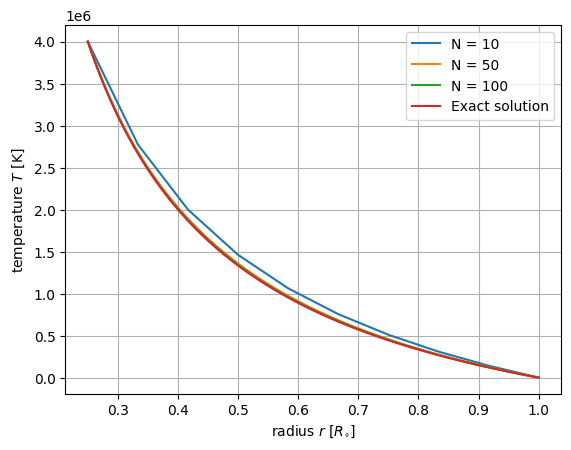

In [3]:
# Creamos las soluciones para los N nodos

T10, r10 = create_system(10)
T50, r50 = create_system(50)
T100, r100 = create_system(100)


# Graficamos

plt.plot(r10, T10, label = "N = 10")
plt.plot(r50, T50, label = "N = 50")
plt.plot(r100, T100, label = "N = 100")
plt.plot(r100, real_solution(r100), label = "Exact solution")

plt.legend()
plt.grid()

plt.xlabel(r"radius $r$ [$R_{\circ}$]")
plt.ylabel(r"temperature $T$ [K]")

plt.show()

In [4]:
# Para comparar errores, vamos a sumar el error relativo en cada punto y dividirlo sobre N
def compare_errors(est, real):
    """ Para comparar el error relativo total """
    return np.sum(np.abs( (est - real) / real )) / est.size


err10 = compare_errors(T10, real_solution(r10))
err50 = compare_errors(T50, real_solution(r50))
err100 = compare_errors(T100, real_solution(r100))

print(f"Error relativo total para N=10: {err10}")
print(f"Error relativo total para N=50: {err50}")
print(f"Error relativo total para N=100: {err100}")

Error relativo total para N=10: 0.09239059819321455
Error relativo total para N=50: 0.020577140393364023
Error relativo total para N=100: 0.010393471037392917


In [5]:
# Ahora, para revisar qué valor de N cumple que su error sea menor al 1% y al 0.01%, empezamos con N=100 puesto que este da un error apenas mayor al 1%

err = 2.0
N = 100

while err > 1.0 / 100.0:
    N += 1
    T, r = create_system(N)
    err = compare_errors(T, real_solution(r))


print(f"Con un N={N} se obtiene un error de err={err * 100}%")


while err > 0.01 / 100.0 and N < 100000:
    N += 1
    T, r = create_system(N)
    err = compare_errors(T, real_solution(r))


print(f"Con un N={N} se obtiene un error de err={err * 100}%")
    

Con un N=104 se obtiene un error de err=0.9997251828064756%
Con un N=10474 se obtiene un error de err=0.009999078562552404%


En general, para un error 

- $\epsilon < 1.0%$ se necesitan $N = 104$ nodos
- $\epsilon < 0.01%$ se necesitan $N = 10474$ nodos, dos órdenes de magnitud más

## Método del disparo: tanque de presión

Resumidamente, se quiere resolver por el método del disparo

$$
    \frac{d^2 u}{dr^2} + \frac{1}{r} \frac{du}{dr} - \frac{u}{r^2} = 0
$$

con condiciones de frontera $u(13) = 0.01007$ y $u(20) = 0.00769$.

Lo primero que se hace es descomponer el sistema en 2 ODEs de primer orden

$$
    \frac{du}{dr} = z, \, u(13) = 0.01007 \qquad \qquad \frac{dz}{dr} = - \frac{1}{r} z + \frac{u}{r^2}, \, z(13) \approx -0.00034
$$

Ahora, lo que nosotros podemos modificar en este problema es el valor de $z_0 = z(13)$, la condición inicial, y lo que deberíamos de obtener al final es que, para un valor dado de $z_0$, podemos obtener el valor deseado de la frontera $u(20)$ luego de aplicar Euler.

In [39]:
h = 1.75
N = 4 
tol = 1e-5

# Creamos el espacio en r
rs = np.array([13.0 + i*h for i in range(N + 1)])

u_req = 0.00769

def system_step(z0):
    """ Hace un paso del sistema """
    def f1(z):
        return z

    def f2(r, u, z):
        return -(1.0/r)*z + u/(r**2)

    # Condiciones iniciales en ambas variables
    us = [0.01007]
    zs = [z0]

    # Hacemos euler en ambas variables
    for r in rs:
        us.append(us[-1] + f1(zs[-1]))
        zs.append(zs[-1] + f2(r, us[-1], zs[-1]))

    return us, zs

# Guesses iniciales de z(13)
z_1 = 0.0
z0 = -0.0034

# Inicializamos las listas
us = zs = None

count = 0
while True:

    # Vamos a guardar las predicciones de ambos guesses de z(13)
    us, zs = system_step(z0)
    pus, pzs = system_step(z_1)
    ub = us[-1]
    pub = pus[-1]

    # Guardamos cuantas iteraciones
    count += 1

    # Revisamos criteio de convergencia
    if abs(u_req - ub) < tol:
        break
    else:
        # Hacemos la interpolación para hallar el nuevo z0 
        temp = z0
        z0 = z0 + (u_req - ub) * (z_1 - z0)/(pub - ub)
        z_1 = z0


print(f"z(13) encontrada: {z0}")
print(f"que genera un u(20): {us[-1]}")
print(f"en {count} iteraciones")

z(13) encontrada: -0.0006388849246923337
que genera un u(20): 0.007690000000000003
en 2 iteraciones


## Ejemplo 1 de ODEs de Orden Superior

Es resolver la siguiente EDO 

$$
    3 \frac{d^2 y}{d x^2} + 2 \frac{dy}{dx} + 5y = e^{-x}; \,\, y(0) = 5, \,\, y'(0) = 7
$$

usando algún integrador que conozcamos.

En la presentación ya se nos dice que las EDOs lineales resultantes son

$$
    \frac{dy}{dx} = z, \,\, y(0) = 5; \qquad \frac{dz}{dx} = \frac{1}{3} \left( e^{-x} - 2z - 5y \right), \,\, z(0) = 7
$$

por lo tanto, resolvemos cada una por Euler.

La solución exacta de esta EDO está dada por 

$$
    y(x) = e^{-\frac{x}{3}} \left[ \frac{29}{6} \cos\left(\frac{\sqrt{14}}{3}\,x\right) + \frac{79\sqrt{14}}{42} \sin\left(\frac{\sqrt{14}}{3}\,x\right) \right] + \frac{e^{-x}}{6}
$$

(_obtenido de Claude_)

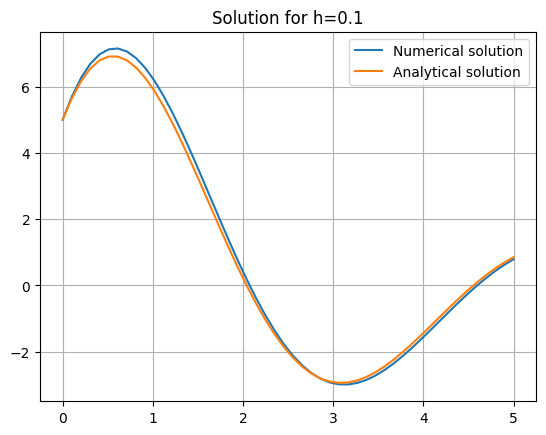

In [59]:


N = 50      # Intervalos
xr = 5.0    # Límite superior
xl = 0.0    # Límite inferior (coincide con la condición inicial)
xs = np.linspace(xl, xr, N)

h = abs(xr - xl)/N  # h

# Creamos las listas para almacenar los zs e ys
zs = [7.0]
ys = [5.0]

# Hacemos Euler
for x in xs[:-1]:

    def dz(x, y, z):
        return (1.0/3.0)*(np.exp(-x) - (2*z) - (5*y))

    # Actualizamos primero y 
    ys.append(ys[-1] + h*zs[-1])
    zs.append(zs[-1] + h*dz(x, ys[-1], zs[-1]))


def y_analytical(x):
    """
    Analytical solution of:
    3y'' + 2y' + 5y = e^(-x), y(0)=5, y'(0)=7
    """
    C1 = 29 / 6
    C2 = 79 * np.sqrt(14) / 42
    sqrt14_over3 = np.sqrt(14) / 3

    y = (np.exp(-x / 3) *
         (C1 * np.cos(sqrt14_over3 * x) +
          C2 * np.sin(sqrt14_over3 * x)) +
         np.exp(-x) / 6)
    return y


# Ahora graficamos el resultado
plt.plot(xs, ys, label = "Numerical solution")
plt.plot(xs, y_analytical(xs), label = "Analytical solution")
plt.title(f"Solution for h={h}")
plt.legend()
plt.grid()
plt.show()
    